# Task 1: Data Cleaning and Exploratory Data Analysis

## Objective
To clean the Superstore Sales dataset and perform exploratory data analysis to derive meaningful business insights.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Dataset Loading

In [46]:
df = pd.read_csv("../data/superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


## Dataset Overview

In [47]:
df.shape

(10800, 21)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

In [49]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Findings

- Checked dataset dimensions.
- Verified data types.
- Generated statistical summary.

## MISSING VALUE ANALYSIS

In [50]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [51]:
df = df.dropna()


In [52]:
df.shape

(9983, 21)

In [53]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [54]:
df.shape

(9983, 21)

## DUPLICATE RECORD ANALYSIS

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.shape

(9983, 21)

## OUTLIER DETECTION 

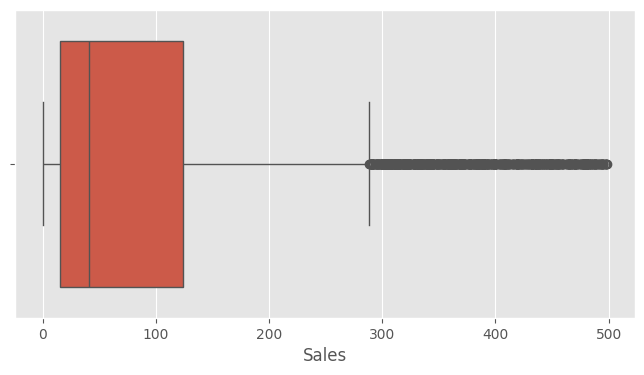

In [66]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales"])
plt.show()


In [104]:
q1=df["Sales"].quantile(0.25)
q3=df["Sales"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
df=df[(df["Sales"]>=lower)&(df["Sales"]<=upper)]
df.shape

(6082, 21)

## Sales Distribution

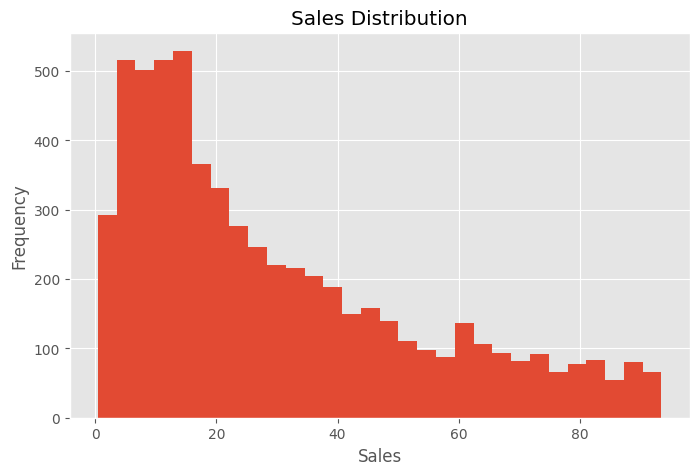

In [96]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## Top 10 States by Sales

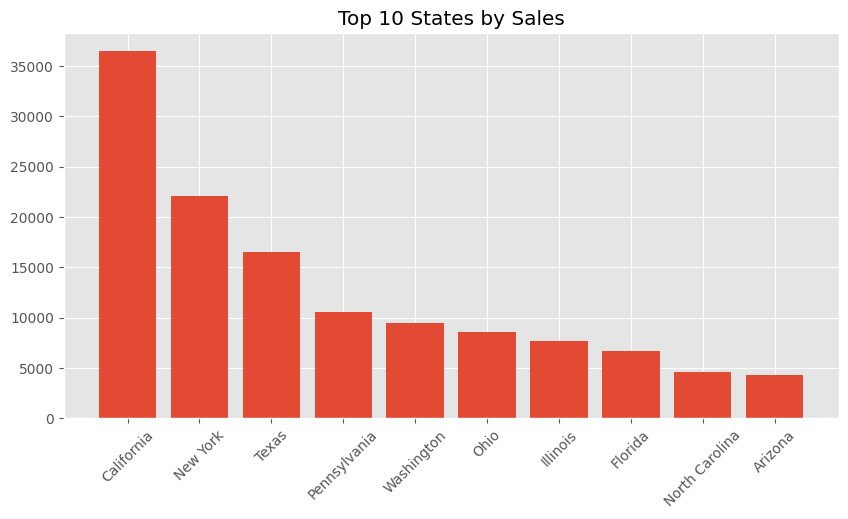

In [98]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(state_sales.index, state_sales.values)
plt.xticks(rotation=45)
plt.title("Top 10 States by Sales")
plt.show()

## Category-wise Sales Analysis

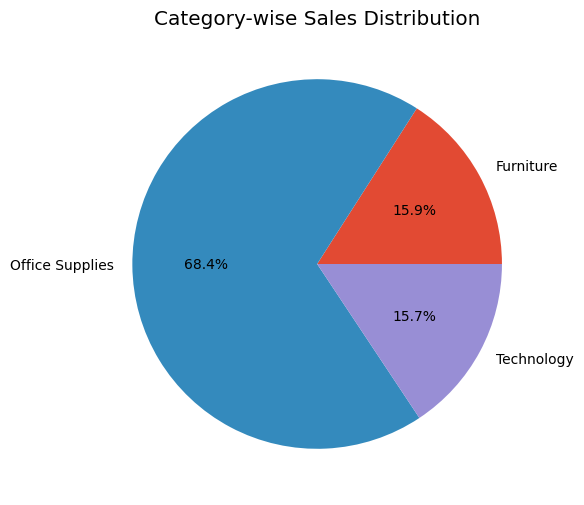

In [99]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%"
)
plt.title("Category-wise Sales Distribution")
plt.show()

## Sales Distribution Analysis

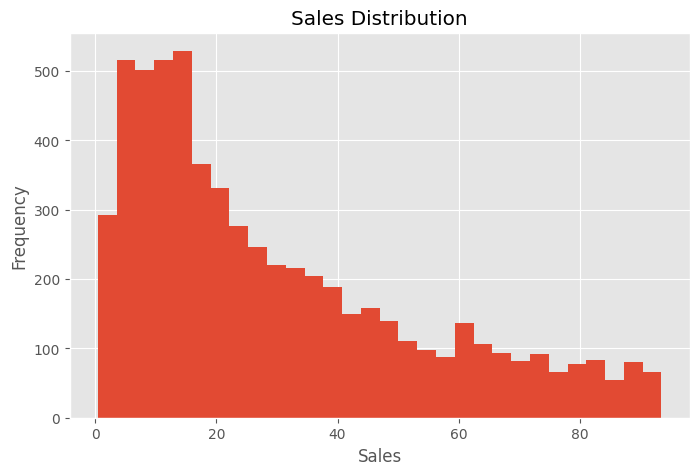

In [100]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## Region-wise Sales

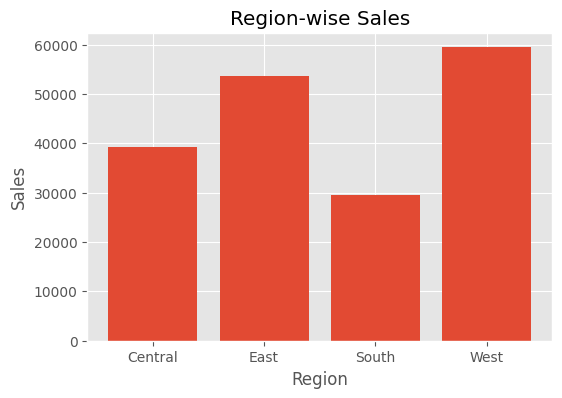

In [101]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,4))
plt.bar(region_sales.index, region_sales.values)
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

## Profit by category

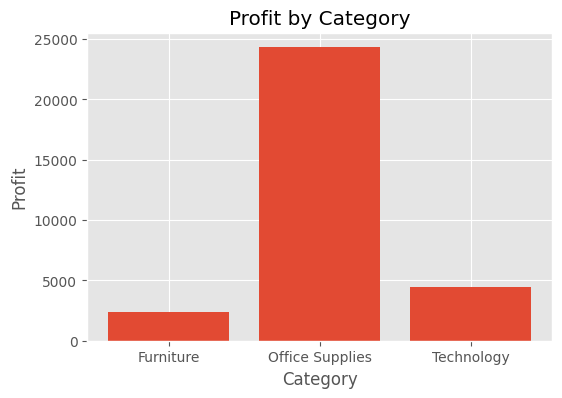

In [102]:
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(6,4))
plt.bar(profit_category.index, profit_category.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

# Key Insights

1. The dataset originally contained 10,800 records.
2. Missing values were identified and handled during data cleaning.
3. California generated the highest sales among all states.
4. Technology and Office Supplies contributed significantly to total sales.
5. The West region recorded higher sales compared to some other regions.
6. Profit varied across categories, indicating differences in business performance.

# Conclusion

Successfully performed Data Cleaning and Exploratory Data Analysis (EDA) on the Superstore Sales Dataset.

Tasks Completed:
- Dataset Exploration
- Missing Value Analysis
- Duplicate Record Analysis
- Data Cleaning
- Sales Distribution Analysis
- State-wise Sales Analysis
- Category-wise Sales Analysis
- Region-wise Sales Analysis
- Profit Analysis

Tools Used:
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

The cleaned dataset is now ready for further analysis and machine learning applications.

In [105]:
import os

os.makedirs("../processed", exist_ok=True)

df.to_csv("../processed/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
